In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

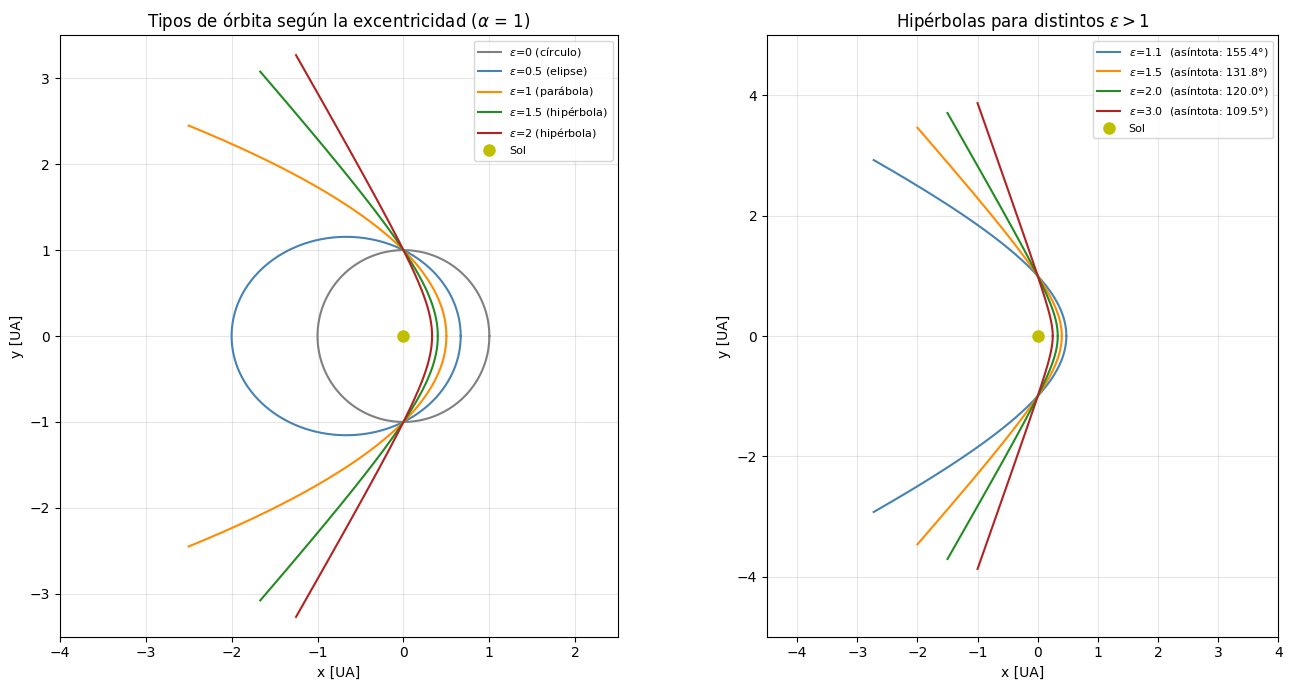

Angulo de asintota para cada hiperbola:
  eps = 1.1   angulo = 155.38 grados
  eps = 1.5   angulo = 131.81 grados
  eps = 2.0   angulo = 120.0 grados
  eps = 3.0   angulo = 109.47 grados


In [6]:
alpha = 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax1 = axes[0]
ax1.set_aspect(1.0)
ax1.set_title(r'Tipos de órbita según la excentricidad ($\alpha$ = 1)')

todos_eps     = [0.0,              0.5,           1.0,            1.5,               2.0]
labels_tipos  = [r'$\varepsilon$=0 (círculo)', r'$\varepsilon$=0.5 (elipse)',
                 r'$\varepsilon$=1 (parábola)', r'$\varepsilon$=1.5 (hipérbola)',
                 r'$\varepsilon$=2 (hipérbola)']
colores_tipos = ['gray', 'steelblue', 'darkorange', 'forestgreen', 'firebrick']

for i in range(len(todos_eps)):
    eps   = todos_eps[i]
    color = colores_tipos[i]
    label = labels_tipos[i]

    if eps < 1:
        theta_fin = 2 * np.pi
    else:
        r_max_grafico = 3.5
        cos_fin = (alpha / r_max_grafico - 1.0) / eps
        if cos_fin < -1.0:
            theta_fin = 0.97 * np.arccos(-1.0 / eps)
        else:
            theta_fin = np.arccos(cos_fin)

    lt_tipo = np.linspace(0.0, theta_fin, 800)

    estado_inicial = [(1 + eps) / alpha, 0.0]
    sol = solve_ivp(derivadas, [0.0, theta_fin], estado_inicial,
                    t_eval=lt_tipo, args=(alpha, 0.0),
                    rtol=1e-9, atol=1e-11)

    thetas_o = sol.t
    r_o      = 1.0 / sol.y[0]
    x_o      = r_o * np.cos(thetas_o)
    y_o      = r_o * np.sin(thetas_o)

    if eps < 1:
        ax1.plot(x_o, y_o, color=color, lw=1.5, label=label)
    else:
        ax1.plot(x_o,  y_o, color=color, lw=1.5, label=label)
        ax1.plot(x_o, -y_o, color=color, lw=1.5)

ax1.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax1.set_xlim(-4.0, 2.5)
ax1.set_ylim(-3.5, 3.5)
ax1.legend(fontsize=8)
ax1.set_xlabel('x [UA]')
ax1.set_ylabel('y [UA]')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_aspect(1.0)
ax2.set_title(r'Hipérbolas para distintos $\varepsilon > 1$')

eps_hipers    = [1.1, 1.5, 2.0, 3.0]
colores_hiper = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

for i in range(len(eps_hipers)):
    eps   = eps_hipers[i]
    color = colores_hiper[i]

    r_max_grafico = 4.0
    cos_fin = (alpha / r_max_grafico - 1.0) / eps
    if cos_fin < -1.0:
        theta_fin = 0.97 * np.arccos(-1.0 / eps)
    else:
        theta_fin = np.arccos(cos_fin)

    lt_h = np.linspace(0.0, theta_fin, 800)

    estado_inicial = [(1 + eps) / alpha, 0.0]
    sol = solve_ivp(derivadas, [0.0, theta_fin], estado_inicial,
                    t_eval=lt_h, args=(alpha, 0.0),
                    rtol=1e-9, atol=1e-11)

    thetas_h = sol.t
    r_h      = 1.0 / sol.y[0]
    x_h      = r_h * np.cos(thetas_h)
    y_h      = r_h * np.sin(thetas_h)

    theta_asintota      = np.arccos(-1.0 / eps)
    ang_asintota_grados = round(np.degrees(theta_asintota), 1)
    etiqueta = r'$\varepsilon$=' + str(eps) + '  (asíntota: ' + str(ang_asintota_grados) + '°)'

    ax2.plot(x_h,  y_h, color=color, lw=1.5, label=etiqueta)
    ax2.plot(x_h, -y_h, color=color, lw=1.5)

ax2.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax2.set_xlim(-4.5, 4.0)
ax2.set_ylim(-5.0, 5.0)
ax2.legend(fontsize=8)
ax2.set_xlabel('x [UA]')
ax2.set_ylabel('y [UA]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'graficos\figura_5_tipo_conicas_segun_epsilon.png', dpi=120, bbox_inches='tight')
plt.show()

print('Angulo de asintota para cada hiperbola:')
for eps in [1.1, 1.5, 2.0, 3.0]:
    theta_asintota = np.arccos(-1.0 / eps)
    print('  eps =', eps, '  angulo =', round(np.degrees(theta_asintota), 2), 'grados')